# Black-Scholes Option Pricing

In this notebook we implement the Black-Scholes model to price
European options.

The objective is to compute the theoretical price of call and put
options using the analytical formula.

## Black-Scholes formula

Price for a European call option:
**C = S N(d1) − K e^(−rT) N(d2)**

Price for a European put option:
**P = K e^(−rT) N(-d2) − S N(-d1)**

where

d1 = [ln(S/K) + (r + σ²/2)T] / (σ√T)

d2 = d1 − σ√T

Variables:

S : current stock price  
K : strike price  
T : time to maturity (years)  
r : risk-free rate  
σ : volatility  
d1 : standardized distance between the current stock price and the strike, taking volatility and time into account.
d2 : adjusted version of d1 used in the option pricing formula and related to the probability of finishing in the money.

In [1]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Importations
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import yfinance as yf

In [3]:
# Model parameters
S = 100      # current price of the underlying asset
K = 110      # strike price of the option
T = 1        # maturity (years)
r = 0.05     # risk-free rate
sigma = 0.2  # volatility


d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

print("d1 =", d1)
print("d2 =", d2)

d1 = -0.12655089902162442
d2 = -0.32655089902162443


In [4]:
# Price of call and put

call_price = S * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
print("Call price:", call_price)

put_price = K * np.exp(-r*T) * norm.cdf(-d2) - S * norm.cdf(-d1)
print("Put price:", put_price)

Call price: 6.040088129724239
Put price: 10.675324824802793


### Test 1 — Sensitivity to the stock price

We verify that:
- the call price increases when the stock price increases
- the put price decreases when the stock price increases

In [5]:
S_values = [80, 90, 100, 110, 120]

print("Test 1: Sensitivity of option prices to the stock price\n")

for S_test in S_values:
    
    d1 = (np.log(S_test/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    call = S_test * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
    put = K * np.exp(-r*T) * norm.cdf(-d2) - S_test * norm.cdf(-d1)
    
    print("Stock price:", S_test)
    print("Call price :", round(call,2))
    print("Put price  :", round(put,2))
    print()

Test 1: Sensitivity of option prices to the stock price

Stock price: 80
Call price : 0.76
Put price  : 25.39

Stock price: 90
Call price : 2.52
Put price  : 17.16

Stock price: 100
Call price : 6.04
Put price  : 10.68

Stock price: 110
Call price : 11.5
Put price  : 6.13

Stock price: 120
Call price : 18.64
Put price  : 3.27



### Test 2 — Put-Call Parity

The Black-Scholes prices must satisfy the Put-Call parity relationship:

C − P = S − K e^(−rT)

This relationship comes from the **absence of arbitrage**, a fundamental
assumption in financial markets.

Two portfolios with identical payoffs at maturity must have the same price today.

Portfolio A:
- one European call option
- cash equal to K e^(−rT)

Portfolio B:
- one European put option
- one share of the underlying asset

Since both portfolios produce the same payoff at maturity, their values today must satisfy:

C + K e^(−rT) = P + S

which leads to the Put-Call parity formula.

When substituting the Black-Scholes formulas for the call and put prices,
the terms involving d1 and d2 simplify thanks to the property of the
standard normal distribution:

N(-x) = 1 − N(x)

This simplification leads directly to:

C − P = S − K e^(−rT)

This test therefore verifies that the implemented pricing formulas are
consistent with the fundamental no-arbitrage condition.

In [6]:
print("Test 2: Put-Call parity\n")

left = call_price - put_price
right = S - K * np.exp(-r * T)

print("Left side  (C - P):", round(left,10))
print("Right side (S - K e^(-rT)):", round(right,10))
print()

print("Difference:", abs(left-right))

Test 2: Put-Call parity

Left side  (C - P): -4.6352366951
Right side (S - K e^(-rT)): -4.6352366951

Difference: 7.105427357601002e-15


## Airbus market data and historical volatility

In this section we apply the Black-Scholes model using real market data
for Airbus stock (AIR.PA).

We estimate historical volatility from the last two years of data and
use it as an input in the pricing model.

In [7]:
# Download Airbus historical prices (from last 2 years to now)
airbus = yf.download("AIR.PA", period="2y", auto_adjust=False)

# Keep adjusted close prices
airbus = airbus[["Adj Close"]].dropna()

airbus.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close
Ticker,AIR.PA
Date,
2024-03-18,156.899612
2024-03-19,159.744980
2024-03-20,161.552200
2024-03-21,162.744171
2024-03-22,163.320938


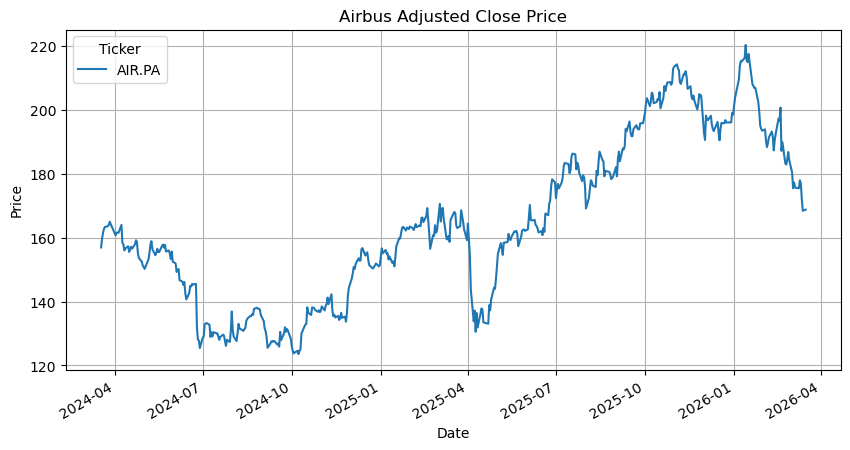

In [8]:
# Plot Airbus price
airbus["Adj Close"].plot(figsize=(10,5))
plt.title("Airbus Adjusted Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

In [9]:
# Compute daily log returns
# Daily log returns are used because they are additive and commonly used in quantitative finance
airbus["log_return"] = np.log(airbus["Adj Close"] / airbus["Adj Close"].shift(1))
airbus = airbus.dropna()
airbus.head()

Price,Adj Close,log_return
Ticker,AIR.PA,
Date,,
2024-03-19,159.744980,0.017972
2024-03-20,161.552200,0.011250
2024-03-21,162.744171,0.007351
2024-03-22,163.320938,0.003538
2024-03-25,163.532425,0.001294


### Volatility estimation

The Black-Scholes model assumes constant volatility.

Since volatility varies over time, we estimate
current volatility using rolling windows
of 20 and 60 trading days.

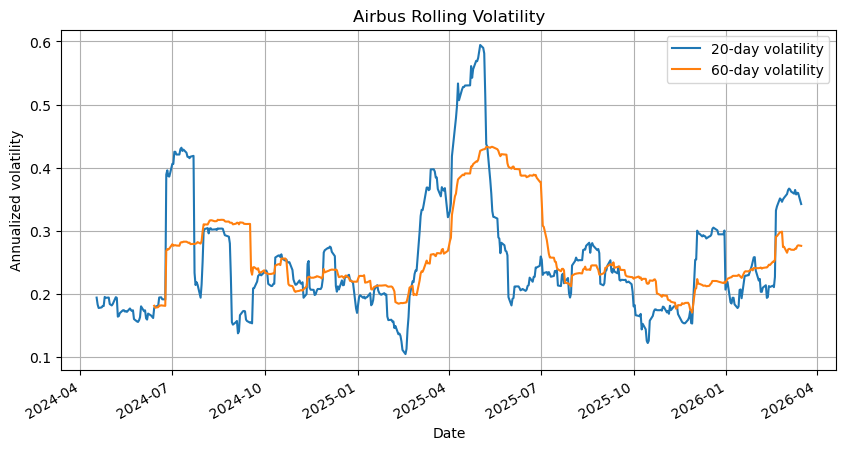

20-day volatility: 0.3424
60-day volatility: 0.2763


In [10]:
# Rolling historical volatility
airbus["vol_20d"] = airbus["log_return"].rolling(20).std() * np.sqrt(252)
airbus["vol_60d"] = airbus["log_return"].rolling(60).std() * np.sqrt(252)

# Volatility plot
plt.figure(figsize=(10,5))
airbus["vol_20d"].plot(label="20-day volatility")
airbus["vol_60d"].plot(label="60-day volatility")
plt.title("Airbus Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized volatility")
plt.legend()
plt.grid(True)
plt.show()


# Latest volatility estimates
sigma_20 = airbus["vol_20d"].dropna().iloc[-1]
sigma_60 = airbus["vol_60d"].dropna().iloc[-1]

print("20-day volatility:", round(sigma_20,4))
print("60-day volatility:", round(sigma_60,4))

In [11]:
# Black-Scholes parameters

# Get latest Airbus price to get S0
latest_airbus = yf.download("AIR.PA",period="5d",auto_adjust=False)
S0 = latest_airbus["Adj Close"].dropna().iloc[-1] 
print("Current Airbus price:", round(S0,4))
print()

r = 0.02
T_30 = 30 / 252
T_90 = 90 / 252


# Strike values around the spot price (from 90% to 110% of the current spot price)
strikes = [0.90 * S0,0.95 * S0,1.00 * S0,1.05 * S0,1.10 * S0]
strikes = [round(k,2) for k in strikes]
print(strikes)

[*********************100%***********************]  1 of 1 completed

Current Airbus price: Ticker
AIR.PA    168.72
Name: 2026-03-16 00:00:00, dtype: float64

[Ticker
AIR.PA    151.85
Name: 2026-03-16 00:00:00, dtype: float64, Ticker
AIR.PA    160.28
Name: 2026-03-16 00:00:00, dtype: float64, Ticker
AIR.PA    168.72
Name: 2026-03-16 00:00:00, dtype: float64, Ticker
AIR.PA    177.16
Name: 2026-03-16 00:00:00, dtype: float64, Ticker
AIR.PA    185.59
Name: 2026-03-16 00:00:00, dtype: float64]


In [12]:
# Black-Scholes pricing functions

def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price


def bs_put(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return put_price



# Compute Black-Scholes pricing table
results = []
for K in strikes:

    results.append({

        "Strike": K,

        "Call_30d_sigma20": bs_call(S0, K, T_30, r, sigma_20),
        "Put_30d_sigma20": bs_put(S0, K, T_30, r, sigma_20),

        "Call_30d_sigma60": bs_call(S0, K, T_30, r, sigma_60),
        "Put_30d_sigma60": bs_put(S0, K, T_30, r, sigma_60),

        "Call_90d_sigma20": bs_call(S0, K, T_90, r, sigma_20),
        "Put_90d_sigma20": bs_put(S0, K, T_90, r, sigma_20),

        "Call_90d_sigma60": bs_call(S0, K, T_90, r, sigma_60),
        "Put_90d_sigma60": bs_put(S0, K, T_90, r, sigma_60)

    })

pricing_table = pd.DataFrame(results).round(4)
pricing_table # The table shows Black-Scholes option prices for different strikes, maturities and volatility estimates.

,Strike,Call_30d_sigma20,Put_30d_sigma20,Call_30d_sigma60,Put_30d_sigma60,Call_90d_sigma20,Put_90d_sigma20,Call_90d_sigma60,Put_90d_sigma60
0,Ticker AIR.PA 151.85 Name: 2026-03-16 00:00...,Ticker AIR.PA 19.085745 Name: 2026-03-16 00...,Ticker AIR.PA 1.854627 Name: 2026-03-16 00:...,Ticker AIR.PA 18.215483 Name: 2026-03-16 00...,Ticker AIR.PA 0.984364 Name: 2026-03-16 00:...,Ticker AIR.PA 23.904429 Name: 2026-03-16 00...,Ticker AIR.PA 5.95365 Name: 2026-03-16 00:0...,Ticker AIR.PA 21.826714 Name: 2026-03-16 00...,Ticker AIR.PA 3.875934 Name: 2026-03-16 00:...
1,Ticker AIR.PA 160.28 Name: 2026-03-16 00:00...,Ticker AIR.PA 12.935959 Name: 2026-03-16 00...,Ticker AIR.PA 4.114793 Name: 2026-03-16 00:...,Ticker AIR.PA 11.62164 Name: 2026-03-16 00:...,Ticker AIR.PA 2.800474 Name: 2026-03-16 00:...,Ticker AIR.PA 18.690333 Name: 2026-03-16 00...,Ticker AIR.PA 9.109554 Name: 2026-03-16 00:...,Ticker AIR.PA 16.243704 Name: 2026-03-16 00...,Ticker AIR.PA 6.662925 Name: 2026-03-16 00:...
2,Ticker AIR.PA 168.72 Name: 2026-03-16 00:00...,Ticker AIR.PA 8.141152 Name: 2026-03-16 00:...,Ticker AIR.PA 7.739914 Name: 2026-03-16 00:...,Ticker AIR.PA 6.609101 Name: 2026-03-16 00:...,Ticker AIR.PA 6.207863 Name: 2026-03-16 00:...,Ticker AIR.PA 14.310801 Name: 2026-03-16 00...,Ticker AIR.PA 13.109951 Name: 2026-03-16 00...,Ticker AIR.PA 11.672407 Name: 2026-03-16 00...,Ticker AIR.PA 10.471557 Name: 2026-03-16 00...
3,Ticker AIR.PA 177.16 Name: 2026-03-16 00:00...,Ticker AIR.PA 4.74739 Name: 2026-03-16 00:0...,Ticker AIR.PA 12.766081 Name: 2026-03-16 00...,Ticker AIR.PA 3.320308 Name: 2026-03-16 00:...,Ticker AIR.PA 11.338999 Name: 2026-03-16 00...,Ticker AIR.PA 10.743059 Name: 2026-03-16 00...,Ticker AIR.PA 17.922138 Name: 2026-03-16 00...,Ticker AIR.PA 8.106058 Name: 2026-03-16 00:...,Ticker AIR.PA 15.285137 Name: 2026-03-16 00...
4,Ticker AIR.PA 185.59 Name: 2026-03-16 00:00...,Ticker AIR.PA 2.568382 Name: 2026-03-16 00:...,Ticker AIR.PA 18.997026 Name: 2026-03-16 00...,Ticker AIR.PA 1.471614 Name: 2026-03-16 00:...,Ticker AIR.PA 17.900258 Name: 2026-03-16 00...,Ticker AIR.PA 7.918788 Name: 2026-03-16 00:...,Ticker AIR.PA 23.467867 Name: 2026-03-16 00...,Ticker AIR.PA 5.450131 Name: 2026-03-16 00:...,Ticker AIR.PA 20.99921 Name: 2026-03-16 00:...


/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/matplotlib/cbook.py:1719: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/matplotlib/cbook.py:1355: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


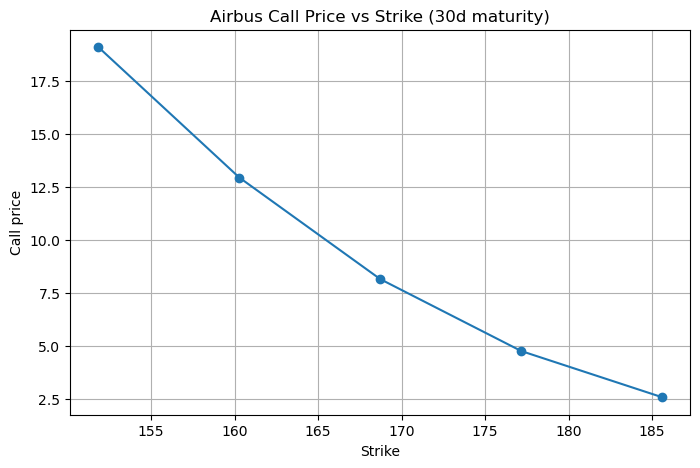

In [13]:
plt.figure(figsize=(8,5))

plt.plot(pricing_table["Strike"],pricing_table["Call_30d_sigma20"],marker="o")

plt.title("Airbus Call Price vs Strike (30d maturity)")
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.grid(True)
plt.show()

The current price of Airbus is 168.72000122070312


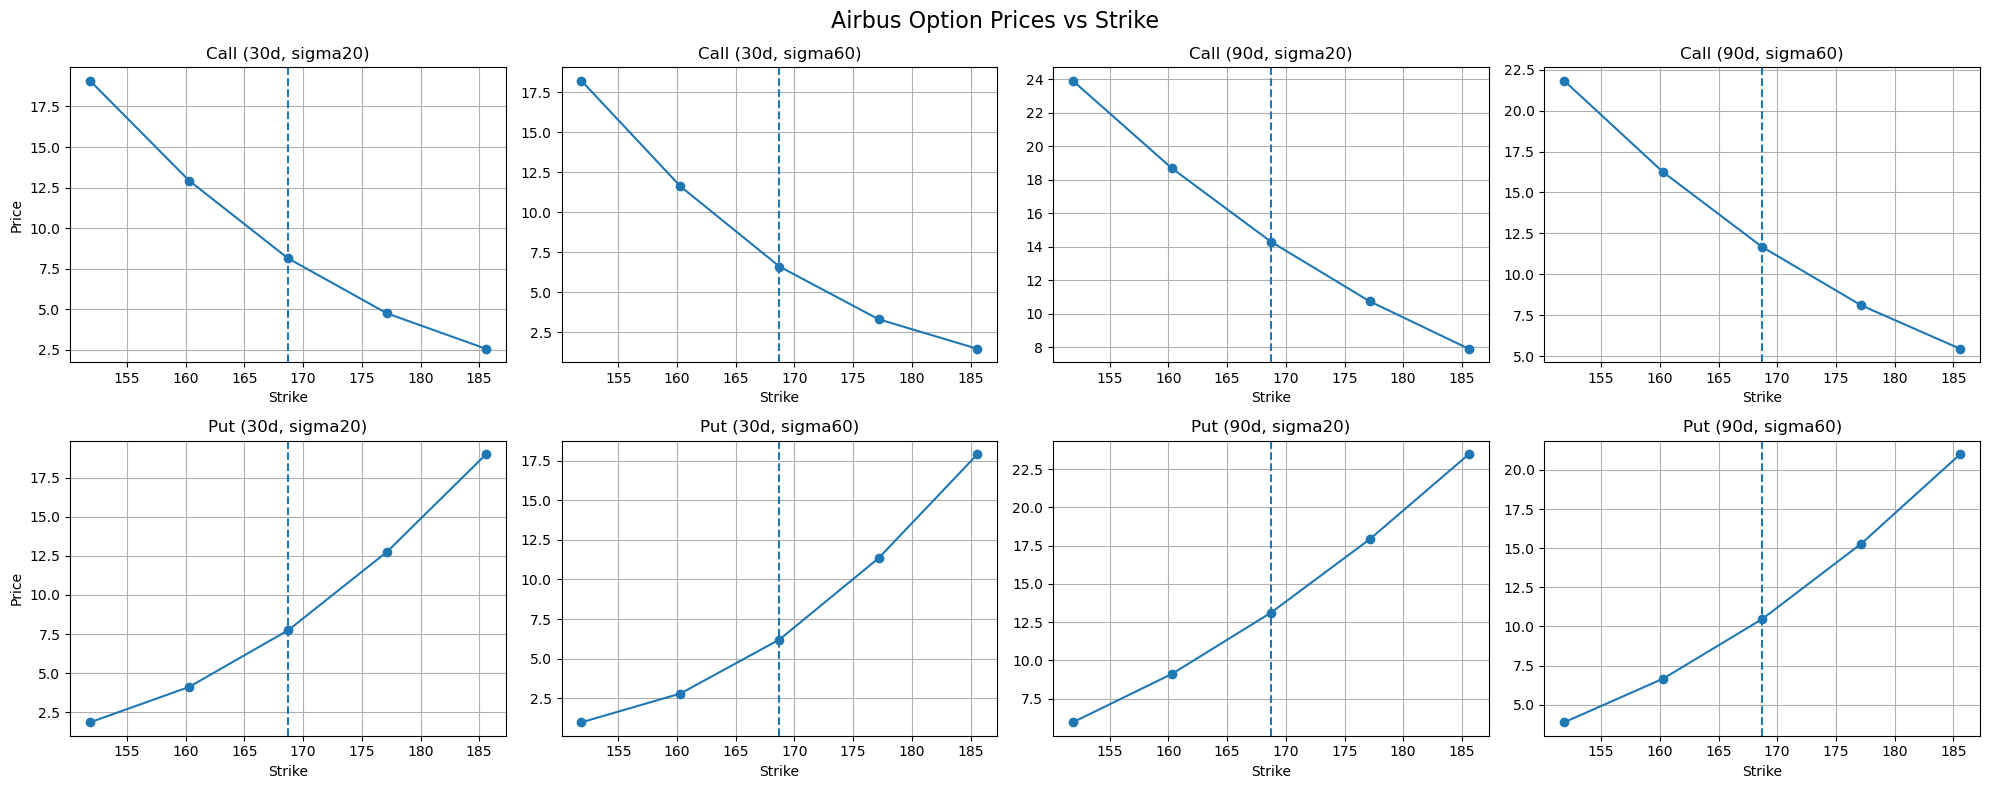

In [14]:
print(f"The current price of Airbus is {S0.iloc[-1]}")

fig, axes = plt.subplots(2, 4, figsize=(20,8))

fig.suptitle("Airbus Option Prices vs Strike", fontsize=16)

# --- CALL OPTIONS ---

axes[0,0].plot(pricing_table["Strike"], pricing_table["Call_30d_sigma20"], marker="o")
axes[0,0].axvline(x=S0.iloc[-1], linestyle="--")
axes[0,0].set_title("Call (30d, sigma20)")
axes[0,0].set_xlabel("Strike")
axes[0,0].set_ylabel("Price")
axes[0,0].grid(True)

axes[0,1].plot(pricing_table["Strike"], pricing_table["Call_30d_sigma60"], marker="o")
axes[0,1].axvline(x=S0.iloc[-1], linestyle="--")
axes[0,1].set_title("Call (30d, sigma60)")
axes[0,1].set_xlabel("Strike")
axes[0,1].grid(True)

axes[0,2].plot(pricing_table["Strike"], pricing_table["Call_90d_sigma20"], marker="o")
axes[0,2].axvline(x=S0.iloc[-1], linestyle="--")
axes[0,2].set_title("Call (90d, sigma20)")
axes[0,2].set_xlabel("Strike")
axes[0,2].grid(True)

axes[0,3].plot(pricing_table["Strike"], pricing_table["Call_90d_sigma60"], marker="o")
axes[0,3].axvline(x=S0.iloc[-1], linestyle="--")
axes[0,3].set_title("Call (90d, sigma60)")
axes[0,3].set_xlabel("Strike")
axes[0,3].grid(True)


# --- PUT OPTIONS ---

axes[1,0].plot(pricing_table["Strike"], pricing_table["Put_30d_sigma20"], marker="o")
axes[1,0].axvline(x=S0.iloc[-1], linestyle="--")
axes[1,0].set_title("Put (30d, sigma20)")
axes[1,0].set_xlabel("Strike")
axes[1,0].set_ylabel("Price")
axes[1,0].grid(True)

axes[1,1].plot(pricing_table["Strike"], pricing_table["Put_30d_sigma60"], marker="o")
axes[1,1].axvline(x=S0.iloc[-1], linestyle="--")
axes[1,1].set_title("Put (30d, sigma60)")
axes[1,1].set_xlabel("Strike")
axes[1,1].grid(True)

axes[1,2].plot(pricing_table["Strike"], pricing_table["Put_90d_sigma20"], marker="o")
axes[1,2].axvline(x=S0.iloc[-1], linestyle="--")
axes[1,2].set_title("Put (90d, sigma20)")
axes[1,2].set_xlabel("Strike")
axes[1,2].grid(True)

axes[1,3].plot(pricing_table["Strike"], pricing_table["Put_90d_sigma60"], marker="o")
axes[1,3].axvline(x=S0.iloc[-1], linestyle="--")
axes[1,3].set_title("Put (90d, sigma60)")
axes[1,3].set_xlabel("Strike")
axes[1,3].grid(True)

plt.tight_layout()
plt.show()